<a href="https://colab.research.google.com/github/Steven10P/Analisis-KDM-PNC/blob/main/notebooks/01_EDA_Datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1: Importaciones y Descarga de Datos

In [1]:

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import pandas as pd


In [2]:


# MNIST
mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True)
print("[OK] MNIST cargado.")

# Fashion MNIST
fmnist = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
print("[OK] Fashion MNIST cargado.")

# SVHN
svhn = torchvision.datasets.SVHN(root='./data', split='train', download=True)
print("[OK] SVHN cargado.")

# GTSRB (Las imágenes tienen tamaños variables, no aplicamos transform por ahora para ver la cruda realidad)
gtsrb = torchvision.datasets.GTSRB(root='./data', split='train', download=True)
print("[OK] GTSRB cargado.")

datasets_dict = {
    'MNIST': mnist,
    'Fashion MNIST': fmnist,
    'SVHN': svhn,
    'GTSRB': gtsrb
}

[OK] MNIST cargado.
[OK] Fashion MNIST cargado.
[OK] SVHN cargado.
[OK] GTSRB cargado.


2: Visualización de Muestras

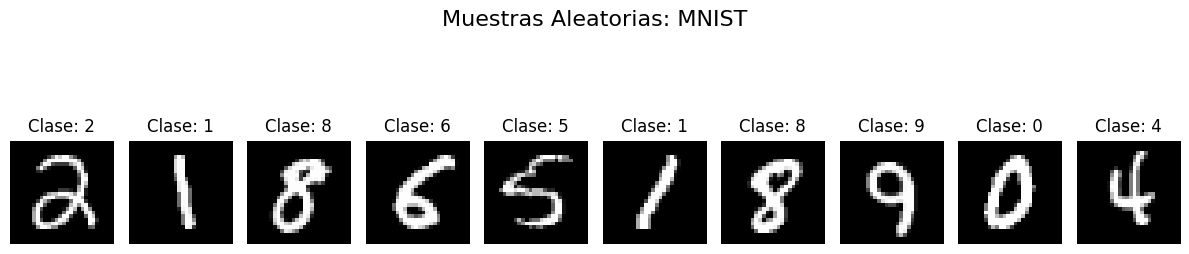

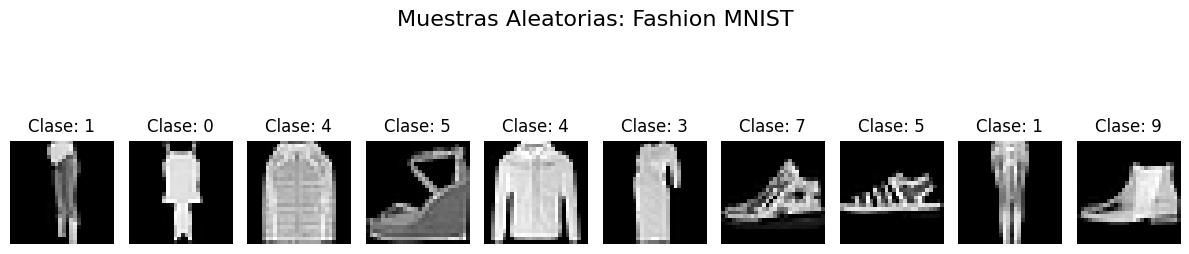

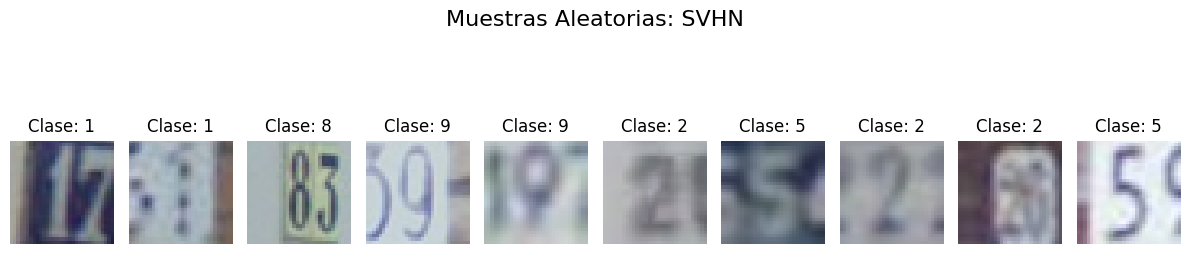

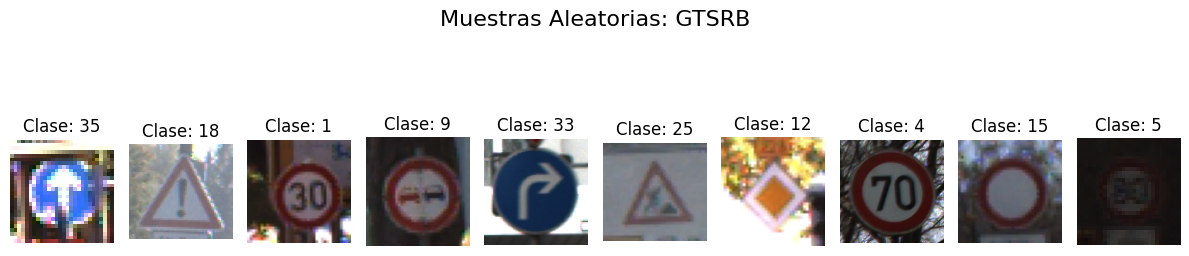

In [3]:

def plot_samples(dataset, name, num_samples=10):
    fig, axes = plt.subplots(1, num_samples, figsize=(12, 3))
    fig.suptitle(f'Muestras Aleatorias: {name}', fontsize=16, y=1.05)

    # SVHN devuelve (imagen, etiqueta), pero la imagen es un array o PIL
    # GTSRB también devuelve (PIL Image, etiqueta)
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    for i, idx in enumerate(indices):
        img, label = dataset[idx]

        # Convertir a numpy para graficar si es necesario
        if isinstance(img, torch.Tensor):
            img = img.permute(1, 2, 0).numpy()

        axes[i].imshow(img, cmap='gray' if name in ['MNIST', 'Fashion MNIST'] else None)
        axes[i].set_title(f'Clase: {label}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

for name, ds in datasets_dict.items():
    plot_samples(ds, name)

3: Distribución de Clases

/tmp/ipykernel_12473/4065700897.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(clases), y=list(frecs), ax=axes[i], palette='viridis')
/tmp/ipykernel_12473/4065700897.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(clases), y=list(frecs), ax=axes[i], palette='viridis')
/tmp/ipykernel_12473/4065700897.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(clases), y=list(frecs), ax=axes[i], palette='viridis')
/tmp/ipykernel_12473/4065700897.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is depre

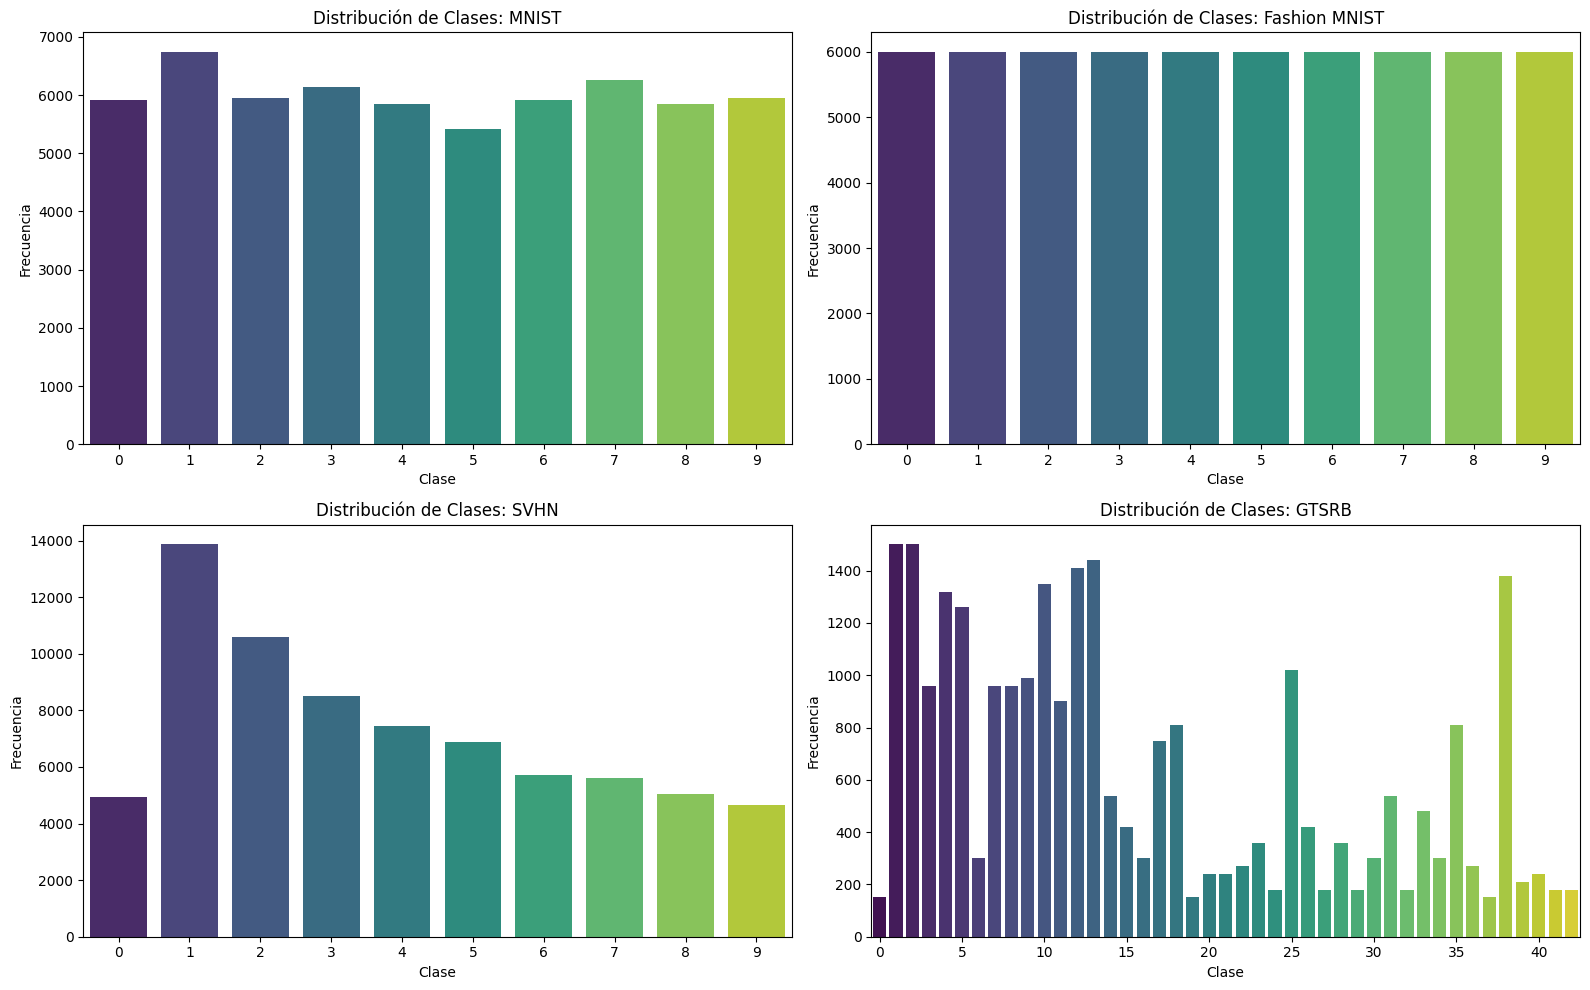

In [4]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (name, ds) in enumerate(datasets_dict.items()):
    # Extraer etiquetas según el formato del dataset
    if name == 'SVHN':
        labels = ds.labels
    elif name == 'GTSRB':
        labels = [label for _, label in ds._samples]
    else:
        labels = ds.targets.numpy()

    # Contar frecuencias
    counts = Counter(labels)
    clases, frecs = zip(*sorted(counts.items()))

    # Graficar
    sns.barplot(x=list(clases), y=list(frecs), ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de Clases: {name}')
    axes[i].set_xlabel('Clase')
    axes[i].set_ylabel('Frecuencia')

    # Ocultar etiquetas X en GTSRB para que no se amontonen (son 43 clases)
    if name == 'GTSRB':
        axes[i].set_xticks(range(0, 43, 5))

plt.tight_layout()
plt.show()

4: Resumen de Dimensionalidad

In [5]:


resumen = []

for name, ds in datasets_dict.items():
    num_samples = len(ds)

    # Tomar la primera imagen para ver propiedades
    img, _ = ds[0]

    if name in ['MNIST', 'Fashion MNIST']:
        size = img.size # PIL Image
        channels = 1
        num_classes = 10
    elif name == 'SVHN':
        size = img.size
        channels = 3
        num_classes = 10
    elif name == 'GTSRB':
        size = "Variable (Ej: {}x{})".format(img.size[0], img.size[1])
        channels = 3
        num_classes = 43

    resumen.append({
        'Dataset': name,
        'Muestras (Train)': num_samples,
        'Resolución Base': size,
        'Canales': channels,
        'Num Clases': num_classes,
        'Balanceado': 'Sí' if name in ['MNIST', 'Fashion MNIST'] else 'No'
    })

df_resumen = pd.DataFrame(resumen)
print(" TABLA DE COMPLEJIDAD DE DATASETS ---")
display(df_resumen)

 TABLA DE COMPLEJIDAD DE DATASETS ---


,Dataset,Muestras (Train),Resolución Base,Canales,Num Clases,Balanceado
0,MNIST,60000,"(28, 28)",1,10,Sí
1,Fashion MNIST,60000,"(28, 28)",1,10,Sí
2,SVHN,73257,"(32, 32)",3,10,No
3,GTSRB,26640,Variable (Ej: 29x30),3,43,No
